In [2]:
""" Libraries configuration for data preprocessing """

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder



In [3]:
data = r'D:\Phone addicted\Smartphone-Addiction-Warning-System-Rebuild-\data\Raw Data\teen_phone_addiction_dataset.csv'
df = pd.read_csv(data)
df

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Jesus Yates,16,Female,New Jennifer,12th,3.9,6.4,53,4,...,0.3,80,15,2.7,1.8,1.0,Other,8,9.4,9.8
2996,2997,Bethany Murray,13,Female,Richardport,8th,3.6,7.3,93,5,...,0.9,45,8,3.1,0.0,0.3,Gaming,9,5.2,5.5
2997,2998,Norman Hughes,14,Other,Rebeccaton,7th,3.2,6.5,98,1,...,0.2,51,13,2.4,0.2,2.4,Social Media,9,5.9,6.2
2998,2999,Barbara Hinton,17,Female,Ramirezmouth,9th,6.7,7.5,67,3,...,1.6,125,17,1.7,2.6,1.5,Browsing,4,6.1,10.0


## Data Understanding


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   

In [5]:
df.isna().sum()

ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

In [6]:
df.describe()

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


In [7]:
df.drop(columns=['ID','Name','Location'], inplace=True)

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

['Gender', 'School_Grade', 'Phone_Usage_Purpose']


In [9]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print(numerical_cols)

['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level']


**Usage composition**

In [10]:
df['Tracked_Hours']    = df['Time_on_Social_Media'] + df['Time_on_Gaming'] + df['Time_on_Education']
df['Untracked_Hours']  = df['Daily_Usage_Hours'] - df['Tracked_Hours']
df['Leisure_Hours']    = df['Time_on_Social_Media'] + df['Time_on_Gaming']   # zeros are real, leave them
df['Social_vs_Gaming'] = df['Time_on_Social_Media'] - df['Time_on_Gaming']

# guard the denominator (floor, not just ==0), THEN divide, THEN fill the resulting NaN
den = df['Daily_Usage_Hours'].where(df['Daily_Usage_Hours'] >= 0.5, np.nan)

df['Leisure_Ratio']   = (df['Leisure_Hours']    / den).fillna((df['Leisure_Hours']    / den).median() , inplace=True)
df['Education_Ratio'] = (df['Time_on_Education'] / den).fillna((df['Time_on_Education'] / den).median(), inplace=True)

In [11]:
df.isnull().sum()

Age                          0
Gender                       0
School_Grade                 0
Daily_Usage_Hours            0
Sleep_Hours                  0
Academic_Performance         0
Social_Interactions          0
Exercise_Hours               0
Anxiety_Level                0
Depression_Level             0
Self_Esteem                  0
Parental_Control             0
Screen_Time_Before_Bed       0
Phone_Checks_Per_Day         0
Apps_Used_Daily              0
Time_on_Social_Media         0
Time_on_Gaming               0
Time_on_Education            0
Phone_Usage_Purpose          0
Family_Communication         0
Weekend_Usage_Hours          0
Addiction_Level              0
Tracked_Hours                0
Untracked_Hours              0
Leisure_Hours                0
Social_vs_Gaming             0
Leisure_Ratio             3000
Education_Ratio           3000
dtype: int64

**Weekend/weekday behavior**

In [12]:
df['Weekend_Escalation'] = df['Weekend_Usage_Hours'] - df['Daily_Usage_Hours']

den = df['Daily_Usage_Hours'].where(df['Daily_Usage_Hours'] >= 0.5, np.nan)
weekend_ratio = df['Weekend_Usage_Hours'] / den
df['Weekend_Ratio'] = weekend_ratio.fillna(weekend_ratio.median() , inplace=True)

**Intensity / compulsivity**


In [13]:
# Replace 0 values with the mean of the column
apps_mean = df['Apps_Used_Daily'].mean()

apps_used = df['Apps_Used_Daily'].replace(0, apps_mean)

# Feature 1: Minutes spent per phone check
df['Minutes_Per_Check'] = (
    df['Daily_Usage_Hours'] * 60
) / df['Phone_Checks_Per_Day']

# Feature 2: Phone checks per app
df['Checks_Per_App'] = (
    df['Phone_Checks_Per_Day'] / apps_used
)

# Feature 3: Daily usage hours per app
df['Hours_Per_App'] = (
    df['Daily_Usage_Hours'] / apps_used
)

**Sleep displacement**

In [14]:
# Sleep deficit relative to 9 hours
df['Sleep_Deficit'] = (9 - df['Sleep_Hours']).clip(lower=0)

# Replace zero sleep hours with the mean
sleep_hours = df['Sleep_Hours'].replace(
    0,
    df['Sleep_Hours'].mean()
)

# Replace zero daily usage with the mean
daily_usage = df['Daily_Usage_Hours'].replace(
    0,
    df['Daily_Usage_Hours'].mean()
)

# Screen time relative to sleep
df['Screen_To_Sleep_Ratio'] = (
    df['Daily_Usage_Hours'] / sleep_hours
)

# Proportion of daily screen time occurring before bed
df['Bedtime_Screen_Share'] = (
    df['Screen_Time_Before_Bed'] / daily_usage
)

Offline life displacement

In [15]:
# 1. Compute Offline Activity
df['Offline_Activity'] = df['Exercise_Hours'] + df['Social_Interactions']

# 2. Replace 0 with mean permanently in the original columns/series
df['Offline_Activity'].replace(0, df['Offline_Activity'].mean(), inplace=True)
df['Daily_Usage_Hours'].replace(0, df['Daily_Usage_Hours'].mean(), inplace=True)

# 3. Calculate ratios
df['Online_To_Offline_Ratio'] = df['Daily_Usage_Hours'] / df['Offline_Activity']
df['Family_To_Screen_Ratio'] = df['Family_Communication'] / df['Daily_Usage_Hours']

C:\Users\MSI\AppData\Local\Temp\ipykernel_34952\227745037.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Offline_Activity'].replace(0, df['Offline_Activity'].mean(), inplace=True)
C:\Users\MSI\AppData\Local\Temp\ipykernel_34952\227745037.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

**Psychological composite**

In [16]:
for c in ['Anxiety_Level', 'Depression_Level', 'Self_Esteem']:
    df[f'{c}_z'] = (df[c] - df[c].mean()) / df[c].std()
df['Distress_Index'] = df[['Anxiety_Level_z', 'Depression_Level_z']].mean(axis=1) - df['Self_Esteem_z']

**Context / moderator**

In [17]:
df['Academic_Per_Usage'] = df['Academic_Performance'] / df['Daily_Usage_Hours']
df['Unsupervised_Usage'] = df['Daily_Usage_Hours'] * (1 - df['Parental_Control'])  # Parental_Control is 0/1
df['Grade_Num'] = df['School_Grade'].str.extract(r'(\d+)').astype(int)  # ordinal, better than one-hot

In [18]:
df.isnull().sum()

Age                           0
Gender                        0
School_Grade                  0
Daily_Usage_Hours             0
Sleep_Hours                   0
Academic_Performance          0
Social_Interactions           0
Exercise_Hours                0
Anxiety_Level                 0
Depression_Level              0
Self_Esteem                   0
Parental_Control              0
Screen_Time_Before_Bed        0
Phone_Checks_Per_Day          0
Apps_Used_Daily               0
Time_on_Social_Media          0
Time_on_Gaming                0
Time_on_Education             0
Phone_Usage_Purpose           0
Family_Communication          0
Weekend_Usage_Hours           0
Addiction_Level               0
Tracked_Hours                 0
Untracked_Hours               0
Leisure_Hours                 0
Social_vs_Gaming              0
Leisure_Ratio              3000
Education_Ratio            3000
Weekend_Escalation            0
Weekend_Ratio              3000
Minutes_Per_Check             0
Checks_P

In [19]:
df['Education_Ratio'] = df['Education_Ratio'].fillna(df['Education_Ratio'].mean())

C:\Users\MSI\AppData\Local\Temp\ipykernel_34952\2659653331.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Education_Ratio'] = df['Education_Ratio'].fillna(df['Education_Ratio'].mean())


In [20]:
raw_col = ['Age',
 'Gender',
 'School_Grade',
 'Daily_Usage_Hours',
 'Sleep_Hours',
 'Academic_Performance',
 'Social_Interactions',
 'Exercise_Hours',
 'Anxiety_Level',
 'Depression_Level',
 'Self_Esteem',
 'Parental_Control',
 'Screen_Time_Before_Bed',
 'Phone_Checks_Per_Day',
 'Apps_Used_Daily',
 'Time_on_Social_Media',
 'Time_on_Gaming',
 'Time_on_Education',
 'Phone_Usage_Purpose',
 'Family_Communication',
 'Weekend_Usage_Hours']

In [21]:
df.drop(columns=raw_col, inplace=True)

In [22]:
df

,Addiction_Level,Tracked_Hours,Untracked_Hours,Leisure_Hours,Social_vs_Gaming,Leisure_Ratio,Education_Ratio,Weekend_Escalation,Weekend_Ratio,Minutes_Per_Check,...,Offline_Activity,Online_To_Offline_Ratio,Family_To_Screen_Ratio,Anxiety_Level_z,Depression_Level_z,Self_Esteem_z,Distress_Index,Academic_Per_Usage,Unsupervised_Usage,Grade_Num
0,10.0,6.5,-2.5,5.3,1.9,None,NaN,4.7,None,2.790698,...,5.1,0.784314,1.000000,1.525594,-0.856794,0.857699,-0.523299,19.500000,4.0,9
1,10.0,6.9,-1.4,5.1,-2.9,None,NaN,-0.2,None,3.437500,...,5.0,1.100000,0.363636,-0.895984,0.536178,-0.890092,0.710189,12.727273,5.5,7
2,9.2,2.2,3.6,1.8,-1.2,None,NaN,-0.1,None,2.540146,...,8.8,0.659091,1.034483,-1.241923,-0.856794,1.556816,-2.606174,16.034483,5.8,11
3,9.8,5.5,-2.4,4.7,1.5,None,NaN,-0.1,None,1.453125,...,9.6,0.322917,2.580645,1.179654,1.580908,-0.890092,2.270372,25.161290,3.1,12
4,8.6,4.6,-2.1,3.5,1.7,None,NaN,1.2,None,1.562500,...,5.1,0.490196,4.000000,-1.587863,-0.160308,-1.589208,0.715123,22.400000,2.5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,9.8,5.5,-1.6,4.5,0.9,None,NaN,5.5,None,2.925000,...,4.9,0.795918,2.051282,0.487775,1.580908,-1.239650,2.273991,13.589744,0.0,12
2996,5.5,3.4,0.2,3.1,3.1,None,NaN,1.6,None,4.800000,...,5.0,0.720000,2.500000,0.833714,0.884421,1.207257,-0.348189,25.833333,0.0,8
2997,6.2,5.0,-1.8,2.6,2.2,None,NaN,2.7,None,3.764706,...,1.0,3.200000,2.812500,-0.550044,-0.856794,1.207257,-1.910676,30.625000,3.2,7
2998,10.0,5.8,0.9,4.3,-0.9,None,NaN,-0.6,None,3.216000,...,3.2,2.093750,0.597015,-0.895984,-0.160308,1.207257,-1.735403,10.000000,6.7,9


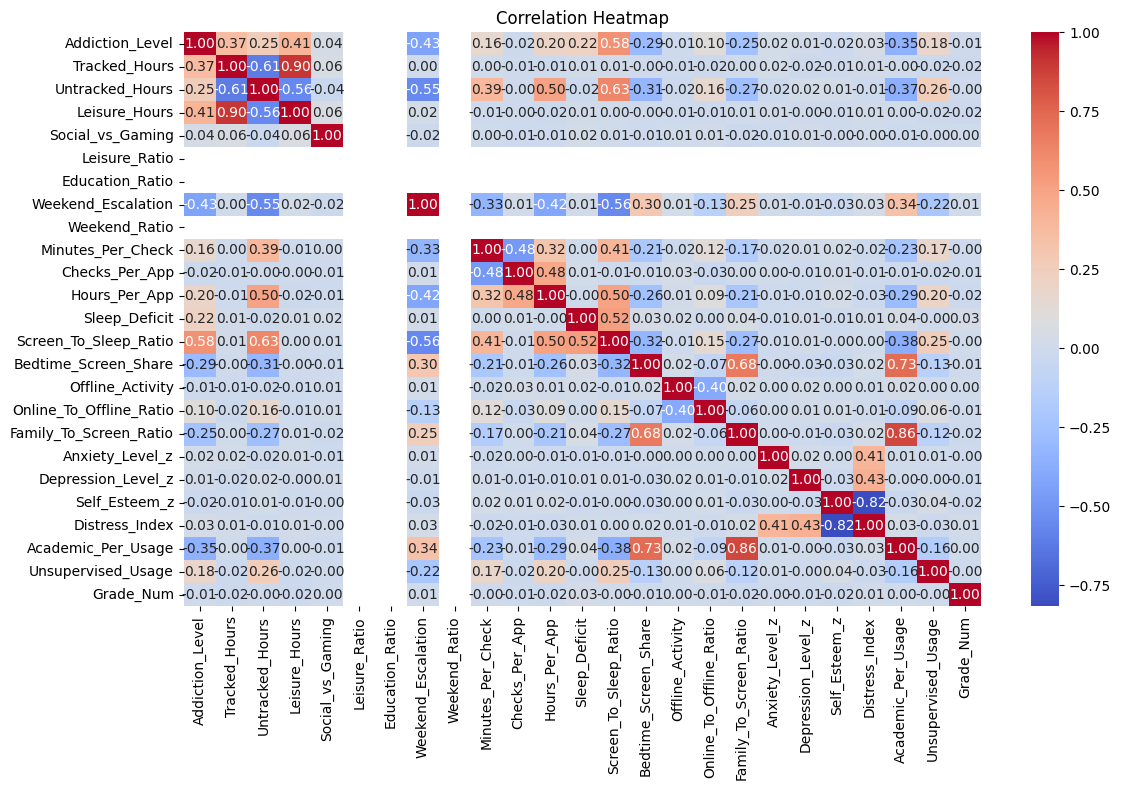

In [23]:
plt.figure(figsize=(12, 8))
plt.title('Correlation Heatmap')
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.tight_layout()
plt.show()

In [24]:
df.isna().sum()

Addiction_Level               0
Tracked_Hours                 0
Untracked_Hours               0
Leisure_Hours                 0
Social_vs_Gaming              0
Leisure_Ratio              3000
Education_Ratio            3000
Weekend_Escalation            0
Weekend_Ratio              3000
Minutes_Per_Check             0
Checks_Per_App                0
Hours_Per_App                 0
Sleep_Deficit                 0
Screen_To_Sleep_Ratio         0
Bedtime_Screen_Share          0
Offline_Activity              0
Online_To_Offline_Ratio       0
Family_To_Screen_Ratio        0
Anxiety_Level_z               0
Depression_Level_z            0
Self_Esteem_z                 0
Distress_Index                0
Academic_Per_Usage            0
Unsupervised_Usage            0
Grade_Num                     0
dtype: int64

In [25]:
df.to_csv('preprocessed_data.csv', index=False)